In [1]:
import xarray as xr
from numpy import asarray
from numpy import savetxt
from numpy import genfromtxt
from sklearn.decomposition import PCA
import numpy as np
import matplotlib.pyplot as plt
import keras
from keras.layers import Input, Dense, Lambda
from keras.models import Model
import tensorflow as tf
from tensorflow.keras import layers

2026-03-09 12:23:01.259458: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:9261] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2026-03-09 12:23:01.259538: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:607] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2026-03-09 12:23:01.689590: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1515] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2026-03-09 12:23:01.978671: I tensorflow/core/platform/cpu_feature_guard.cc:182] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: SSE4.1 SSE4.2 AVX AVX2 AVX512F FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


In [2]:
scaled_input_ohc_train = genfromtxt('/glade/u/home/ewisinski/e3sm_autoencoder/standardscaler/newcoords/randomsampling/fromjohn/ohc700_train_robustscaler.csv', delimiter=',')
scaled_input_ohc_test = genfromtxt('/glade/u/home/ewisinski/e3sm_autoencoder/standardscaler/newcoords/randomsampling/fromjohn/ohc700_test_robustscaler.csv', delimiter=',')

scaled_input_sst_train = genfromtxt('/glade/u/home/ewisinski/e3sm_autoencoder/standardscaler/newcoords/randomsampling/fromjohn/sst_train_robustscaler.csv', delimiter=',')
scaled_input_sst_test = genfromtxt('/glade/u/home/ewisinski/e3sm_autoencoder/standardscaler/newcoords/randomsampling/fromjohn/sst_test_robustscaler.csv', delimiter=',')

scaled_input_olr_train = genfromtxt('/glade/u/home/ewisinski/e3sm_autoencoder/standardscaler/newcoords/randomsampling/fromjohn/olr_train_robustscaler.csv', delimiter=',')
scaled_input_olr_test = genfromtxt('/glade/u/home/ewisinski/e3sm_autoencoder/standardscaler/newcoords/randomsampling/fromjohn/olr_test_robustscaler.csv', delimiter=',')

In [3]:
# load netcdf files with time component 
sequential_input_ohc_train = xr.load_dataarray('/glade/u/home/ewisinski/e3sm_autoencoder/standardscaler/newcoords/randomsampling/fromjohn/ohc700_train_robustscaler.nc')
sequential_input_ohc_test = xr.load_dataarray('/glade/u/home/ewisinski/e3sm_autoencoder/standardscaler/newcoords/randomsampling/fromjohn/ohc700_test_robustscaler.nc')

sequential_input_olr_train = xr.load_dataarray('/glade/u/home/ewisinski/e3sm_autoencoder/standardscaler/newcoords/randomsampling/fromjohn/olr_train_robustscaler.nc')
sequential_input_olr_test = xr.load_dataarray('/glade/u/home/ewisinski/e3sm_autoencoder/standardscaler/newcoords/randomsampling/fromjohn/olr_test_robustscaler.nc')

sequential_input_sst_train = xr.load_dataarray('/glade/u/home/ewisinski/e3sm_autoencoder/standardscaler/newcoords/randomsampling/fromjohn/sst_train_robustscaler.nc')
sequential_input_sst_test = xr.load_dataarray('/glade/u/home/ewisinski/e3sm_autoencoder/standardscaler/newcoords/randomsampling/fromjohn/sst_test_robustscaler.nc')

In [4]:
# Concatenate the train and test datasets along the 'time' dimension
ohc_combined = xr.concat([sequential_input_ohc_train, sequential_input_ohc_test], dim='time')
olr_combined = xr.concat([sequential_input_olr_train, sequential_input_olr_test], dim='time')
sst_combined = xr.concat([sequential_input_sst_train, sequential_input_sst_test], dim='time')

In [5]:
# use sort by for sequential data along time dimension
ohc_sequential = ohc_combined.sortby('time')
olr_sequential = olr_combined.sortby('time')
sst_sequential = sst_combined.sortby('time')

In [6]:
sst_sequential

<xarray.DataArray (time: 6000, newdim: 2968)> Size: 71MB
array([[-0.46650478, -0.3197793 , -0.29813683, ..., -0.55164415,
        -0.5829566 , -0.66701674],
       [-0.17773718, -0.21565889, -0.21351056, ..., -0.23025233,
        -0.18700024, -0.21649799],
       [ 0.10382219,  0.08966852,  0.05962231, ..., -0.35251725,
        -0.27474537, -0.17154494],
       ...,
       [ 1.4205452 ,  1.400869  ,  1.4167161 , ...,  0.22103727,
         0.25323433,  0.22178286],
       [ 1.0547311 ,  1.0982207 ,  1.1158875 , ..., -0.3618258 ,
        -0.3364225 , -0.292119  ],
       [-0.14510034, -0.11480391, -0.11065638, ..., -0.519485  ,
        -0.6436    , -0.6071442 ]], dtype=float32)
Coordinates:
  * time     (time) object 48kB 0001-01-01 00:00:00 ... 0500-12-01 00:00:00
    month    (time) int64 48kB 1 2 3 4 5 6 7 8 9 10 ... 3 4 5 6 7 8 9 10 11 12
    lat      (newdim) float64 24kB -9.5 -9.5 -9.5 -9.5 -9.5 ... 9.5 9.5 9.5 9.5
    lon      (newdim) float64 24kB 130.5 131.5 132.5 133.5 ... 277.5 278.5 279.5
Dimensions without coordinates: newdim

In [7]:
ohc_sequential

<xarray.DataArray (time: 6000, newdim: 2960)> Size: 71MB
array([[-0.06281169, -0.20906061, -0.18186705, ...,  0.62362224,
         0.83531636,  0.61176914],
       [ 0.03483214, -0.06134811, -0.01326702, ...,  0.28284457,
         0.55402124,  0.5225092 ],
       [-0.05450004, -0.07871224, -0.10955569, ...,  0.18483937,
         0.28161588,  0.22350661],
       ...,
       [ 0.8442785 ,  0.84061056,  0.7513687 , ..., -0.2521005 ,
        -0.36358503, -0.23370646],
       [ 0.88659567,  0.8248726 ,  0.7177427 , ..., -0.32499006,
        -0.5276498 , -0.35859805],
       [ 0.68769425,  0.63446355,  0.54791397, ..., -0.6282569 ,
        -0.96252984, -0.82144856]], dtype=float32)
Coordinates:
  * time     (time) object 48kB 0001-01-01 00:00:00 ... 0500-12-01 00:00:00
    month    (time) int64 48kB 1 2 3 4 5 6 7 8 9 10 ... 3 4 5 6 7 8 9 10 11 12
    lat      (newdim) float64 24kB -9.5 -9.5 -9.5 -9.5 -9.5 ... 9.5 9.5 9.5 9.5
    lon      (newdim) float64 24kB 130.5 131.5 132.5 133.5 ... 277.5 278.5 279.5
Dimensions without coordinates: newdim

In [8]:
olr_sequential

<xarray.DataArray (time: 6000, newdim: 2662)> Size: 64MB
array([[ 0.24241254,  0.30834833,  0.22684942, ...,  0.23112747,
         0.29370552,  0.37244037],
       [-0.926759  , -0.5931658 , -0.07895295, ...,  0.30462354,
         0.35614526,  0.43503544],
       [ 1.3475112 ,  1.1852772 ,  0.91891044, ..., -0.31582242,
        -0.2003353 ,  0.01002645],
       ...,
       [ 0.10129009,  0.15584187,  0.18799162, ..., -0.90907973,
        -1.1965964 , -1.5710752 ],
       [-0.38905463, -0.17948021, -0.36370125, ...,  2.4602287 ,
         2.3406508 ,  1.9990622 ],
       [-2.331803  , -2.1585054 , -2.1295793 , ...,  0.68693286,
         0.7712001 ,  0.86353195]], dtype=float32)
Coordinates:
  * time     (time) object 48kB 0001-01-01 00:00:00 ... 0500-12-01 00:00:00
    month    (time) int64 48kB 1 2 3 4 5 6 7 8 9 10 ... 3 4 5 6 7 8 9 10 11 12
    lat      (newdim) float64 21kB -9.895 -9.895 -9.895 ... 9.895 9.895 9.895
    lon      (newdim) float64 21kB 130.0 131.2 132.5 133.8 ... 277.5 278.8 280.0
Dimensions without coordinates: newdim

In [9]:
pca_sst = PCA(n_components=20)
pca_sst.fit(sst_sequential)

pca_ohc = PCA(n_components=20)
pca_ohc.fit(ohc_sequential)

pca_olr = PCA(n_components=20)
pca_olr.fit(olr_sequential)

PCA(n_components=20)

In [10]:
# explained variance ratio
evr_sst = pca_sst.explained_variance_ratio_
evr_ohc = pca_ohc.explained_variance_ratio_
evr_olr = pca_olr.explained_variance_ratio_

In [11]:
cum_evr_sst = np.cumsum(evr_sst)
cum_evr_ohc = np.cumsum(evr_ohc)
cum_evr_olr = np.cumsum(evr_olr)

In [12]:
print("Explained SST variance ratio (20 comps):", evr_sst)
print("Cumulative SST variance explained:", cum_evr_sst[-1])

print("Explained OHC variance ratio (20 comps):", evr_ohc)
print("Cumulative OHC variance explained:", cum_evr_ohc[-1])

print("Explained OLR variance ratio (20 comps):", evr_olr)
print("Cumulative OLR variance explained:", cum_evr_olr[-1])

Explained SST variance ratio (20 comps): [0.65319353 0.09016252 0.04360462 0.02890208 0.02523217 0.01722638
 0.0118677  0.01025756 0.00851807 0.00717513 0.00646487 0.00503164
 0.00493755 0.00450832 0.00409973 0.00371766 0.00341271 0.00306136
 0.00278495 0.00230833]
Cumulative SST variance explained: 0.9364669
Explained OHC variance ratio (20 comps): [0.46913156 0.15762092 0.07749989 0.05160663 0.03684784 0.02706054
 0.02056483 0.0142599  0.01149119 0.01012186 0.00887727 0.00799375
 0.00717328 0.00680927 0.00568291 0.00507288 0.00444345 0.00391361
 0.00371295 0.00326897]
Cumulative OHC variance explained: 0.93315357
Explained OLR variance ratio (20 comps): [0.24903911 0.11359642 0.06428225 0.05567467 0.04499183 0.0370407
 0.0351283  0.02927778 0.0251657  0.02281105 0.02020476 0.01947235
 0.01613363 0.01498992 0.01405667 0.01168829 0.01067451 0.00979133
 0.0083896  0.00800373]
Cumulative OLR variance explained: 0.81041265


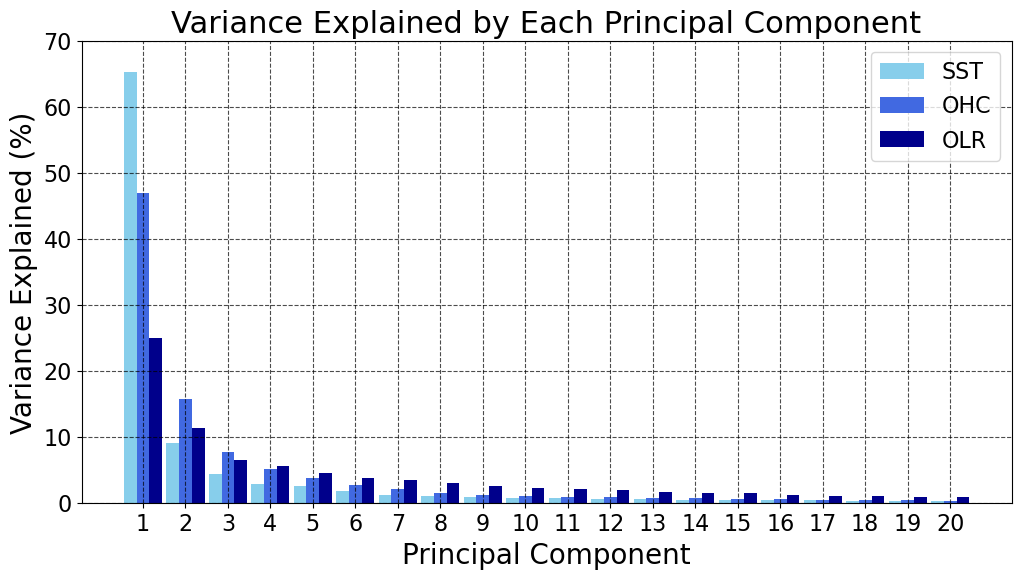

In [13]:
n_pcs = 20
x = np.arange(1, n_pcs + 1)  # the x locations for the groups
width = 0.3  # width of each bar

plt.figure(figsize=(12, 6))

plt.bar(x - width, evr_sst * 100, width=width, color='skyblue', label='SST')
plt.bar(x, evr_ohc * 100, width=width, color='royalblue', label='OHC')
plt.bar(x + width, evr_olr * 100, width=width, color='darkblue', label='OLR')

#plt.bar(x - width, fve_sst * 100, width=width, color='indianred', label='SST VAE')
#plt.bar(x, fve_ohc * 100, width=width, color='red', label='OHC VAE')
#plt.bar(x + width, fve_olr * 100, width=width, color='darkred', label='OLR VAE')

plt.xlabel('Principal Component', fontsize=20)
plt.ylabel('Variance Explained (%)', fontsize=20)
plt.title('Variance Explained by Each Principal Component', fontsize=22)
plt.xticks(x, fontsize=16)
plt.yticks(fontsize=16)
plt.ylim(0, 70)
plt.legend(fontsize=16)
plt.grid(True)
plt.grid(True, linestyle='--', color='black', alpha=0.7)
#plt.savefig('pca_0304.pdf', bbox_inches='tight')
plt.show()

## vae

In [14]:
# sanity checks
print(scaled_input_sst_train.shape,
     scaled_input_sst_test.shape,
     scaled_input_ohc_train.shape,
     scaled_input_ohc_test.shape,
     scaled_input_olr_train.shape,
     scaled_input_olr_test.shape)

(4800, 2968) (1200, 2968) (4800, 2960) (1200, 2960) (4800, 2662) (1200, 2662)


In [15]:
# check input shape for sst
input_shape_sst = scaled_input_sst_train.shape[1]
print(input_shape_sst)

# check input shape for ssh
input_shape_ohc = scaled_input_ohc_train.shape[1]
print(input_shape_ohc)

# check input shape for zonal stress
input_shape_olr = scaled_input_olr_train.shape[1]
print(input_shape_olr)

2968
2960
2662


In [16]:
# set random seed
keras.utils.set_random_seed(1)

In [17]:
# define latent space
latent_dim = 20

In [18]:
# sst input
input_sst = Input(shape=(np.int64(input_shape_sst),), name='input_sst')
print(input_sst.shape)

# add 2 dense layers
encoded_sst_layer1 = Dense(400, activation='tanh')(input_sst)
encoded_sst_layer2 = Dense(250, activation='tanh')(encoded_sst_layer1)
encoded_sst_layer3 = Dense(180, activation='tanh')(encoded_sst_layer2)
encoded_sst_layer4 = Dense(100, activation='tanh')(encoded_sst_layer3)
encoded_sst_layer5 = Dense(30, activation='tanh')(encoded_sst_layer4)

# ohc input
input_ohc = Input(shape=(np.int64(input_shape_ohc),), name='input_ohc')
print(input_ohc.shape)

# add 2 dense layers (again)
encoded_ohc_layer1 = Dense(400, activation='tanh')(input_ohc)
encoded_ohc_layer2 = Dense(250, activation='tanh')(encoded_ohc_layer1)
encoded_ohc_layer3 = Dense(180, activation='tanh')(encoded_ohc_layer2)
encoded_ohc_layer4 = Dense(100, activation='tanh')(encoded_ohc_layer3)
encoded_ohc_layer5 = Dense(30, activation='tanh')(encoded_ohc_layer4)

# zonal stress input 
# ssh input
input_olr = Input(shape=(np.int64(input_shape_olr),),
                          name='input_olr')
print(input_olr.shape)

# add 2 dense layers (again)
encoded_olr_layer1 = Dense(400, activation='tanh')(input_olr)
encoded_olr_layer2 = Dense(250, activation='tanh')(encoded_olr_layer1)
encoded_olr_layer3 = Dense(180, activation='tanh')(encoded_olr_layer2)
encoded_olr_layer4 = Dense(100, activation='tanh')(encoded_olr_layer3)
encoded_olr_layer5 = Dense(30, activation='tanh')(encoded_olr_layer4)

(None, 2968)


2026-03-09 12:24:31.062844: E external/local_xla/xla/stream_executor/cuda/cuda_driver.cc:274] failed call to cuInit: CUDA_ERROR_NO_DEVICE: no CUDA-capable device is detected


(None, 2960)
(None, 2662)


In [19]:
# concatenate inputs before passing through latent space
encoder_output_concat = keras.layers.Concatenate()([encoded_sst_layer5,
                        encoded_ohc_layer5,
                        encoded_olr_layer5]
                      )

In [20]:
# create latent space with z_mean and z_log_var
# this will create dense layers with 2 nodes because of latent_dim 

z_mean = Dense(latent_dim, name='z_mean')(encoder_output_concat)
z_log_var = Dense(latent_dim, name='z_log_var')(encoder_output_concat)

In [21]:
# reparameterization trick 
# "we now treat random sampling as a noise term
# the standard normal is a gaussian distribution with mean mu = 0 and sigma = 1
# https://medium.com/@weidagang/demystifying-neural-networks-variational-autoencoders-6a44e75d0271

def sampling(args):
    z_mean, z_log_var = args
    
    epsilon = keras.backend.random_normal(shape=keras.backend.shape(z_mean), mean=0., stddev=1.)
    return z_mean + keras.backend.exp(z_log_var / 2) * epsilon

In [22]:
z = Lambda(sampling, output_shape=(latent_dim,), name='z_sampling')([z_mean, z_log_var])

In [23]:
# build decoder for each variable from the latent space
# sst
decoded1_sst = Dense(30, activation='tanh')(z)
decoded2_sst = Dense(100, activation='tanh')(decoded1_sst)
decoded3_sst = Dense(180, activation='tanh')(decoded2_sst)
decoded4_sst = Dense(250, activation='tanh')(decoded3_sst)
decoded5_sst = Dense(400, activation='tanh')(decoded4_sst)
output_sst = Dense(np.int64(input_shape_sst), activation='linear', name='output_sst')(decoded5_sst)
print(output_sst.shape)

# build decoder for each variable from the latent space
# ohc
decoded1_ohc = Dense(30, activation='tanh')(z)
decoded2_ohc = Dense(100, activation='tanh')(decoded1_ohc)
decoded3_ohc = Dense(180, activation='tanh')(decoded2_ohc)
decoded4_ohc = Dense(250, activation='tanh')(decoded3_ohc)
decoded5_ohc = Dense(400, activation='tanh')(decoded4_ohc)
output_ohc = Dense(np.int64(input_shape_ohc), activation='linear', name='output_ohc')(decoded5_ohc)
print(output_ohc.shape)

# build decoder for each variable from the latent space
# zonal stress
decoded1_olr = Dense(30, activation='tanh')(z)
decoded2_olr = Dense(100, activation='tanh')(decoded1_olr)
decoded3_olr = Dense(180, activation='tanh')(decoded2_olr)
decoded4_olr = Dense(250, activation='tanh')(decoded3_olr)
decoded5_olr = Dense(400, activation='tanh')(decoded4_olr)
output_olr = Dense(
    np.int64(input_shape_olr), activation='linear', name='output_olr')(decoded5_olr)
print(output_olr.shape)

(None, 2968)
(None, 2960)
(None, 2662)


In [24]:
# final VAE model
vae = Model(inputs=[input_sst, input_ohc, input_olr], 
            outputs= [output_sst, output_ohc, output_olr]
                 )

In [25]:
vae.summary()

Model: "model"
__________________________________________________________________________________________________
 Layer (type)                Output Shape                 Param #   Connected to                  
 input_sst (InputLayer)      [(None, 2968)]               0         []                            
                                                                                                  
 input_ohc (InputLayer)      [(None, 2960)]               0         []                            
                                                                                                  
 input_olr (InputLayer)      [(None, 2662)]               0         []                            
                                                                                                  
 dense (Dense)               (None, 400)                  1187600   ['input_sst[0][0]']           
                                                                                              

In [26]:
# create class for custom losses
# this will return losses of each variable during training
# can also define weights here

class VAELossLayer(layers.Layer):
    def __init__(self, input_shape_sst, input_shape_ohc, input_shape_olr, kl_weight=0.0005, **kwargs):
        super(VAELossLayer, self).__init__(**kwargs)
        self.input_shape_sst = input_shape_sst
        self.input_shape_ohc = input_shape_ohc
        self.input_shape_olr = input_shape_olr
        self.kl_weight = kl_weight

    def call(self, inputs):
        input_sst, input_ohc, input_olr, output_sst, output_ohc, output_olr, z_mean, z_log_var = inputs
        #print(inputs.shape)

        # Reconstruction loss
        reconstruction_loss_sst = keras.losses.mse(input_sst, output_sst)# * self.input_shape_sst
        reconstruction_loss_ohc = keras.losses.mse(input_ohc, output_ohc)# * self.input_shape_ohc
        reconstruction_loss_olr = keras.losses.mse(input_olr, output_olr)# * self.input_shape_olr

        self.add_metric(reconstruction_loss_sst, name="sst_loss", aggregation="mean")
        self.add_metric(reconstruction_loss_ohc, name="ohc_loss", aggregation="mean")
        self.add_metric(reconstruction_loss_olr, name="olr_loss", aggregation="mean")
        
        reconstruction_loss = reconstruction_loss_sst + reconstruction_loss_ohc + reconstruction_loss_olr

        kl_loss = 1 + z_log_var - tf.square(z_mean) - tf.exp(z_log_var)
        kl_loss = tf.reduce_sum(kl_loss, axis=-1) * -0.5
        kl_loss = kl_loss * self.kl_weight

        # Total loss
        total_loss = tf.reduce_mean(reconstruction_loss) + tf.reduce_mean(kl_loss)
        self.add_loss(total_loss)
        self.add_metric(kl_loss, name="kl_loss", aggregation="mean")

        return output_sst, output_ohc, output_olr, total_loss, kl_loss, reconstruction_loss_sst, reconstruction_loss_ohc, reconstruction_loss_olr  # including kl_loss as output

In [27]:
# Add the custom loss layer
outputs = VAELossLayer(input_shape_sst, input_shape_ohc, input_shape_olr)([
    input_sst, input_ohc, input_olr, output_sst, output_ohc, output_olr, z_mean, z_log_var
])

In [28]:
# Define VAE model
vae = keras.Model(inputs=[input_sst, input_ohc, input_olr], outputs=outputs)

opt = keras.optimizers.Adam(learning_rate=0.0003)
vae.compile(optimizer=opt,
            run_eagerly=True)

In [29]:
# Fit the model
vae_model_history = vae.fit(
    x=[scaled_input_sst_train, scaled_input_ohc_train, scaled_input_olr_train],
    #y=[scaled_input_sst_train, scaled_input_ohc_train, scaled_input_olr_train],
    y=None,  # `y` is None because the loss is calculated within the model
    epochs=150,
    batch_size=256,
    validation_split=0.25
)

Epoch 1/150
15/15 [==============================] - 5s 269ms/step - loss: 2.5540 - sst_loss: 0.8168 - ohc_loss: 0.7057 - olr_loss: 1.0621 - kl_loss: 0.0099 - val_loss: 2.1870 - val_sst_loss: 0.6010 - val_ohc_loss: 0.5652 - val_olr_loss: 0.9930 - val_kl_loss: 0.0131
Epoch 2/150
15/15 [==============================] - 4s 249ms/step - loss: 1.9241 - sst_loss: 0.5052 - ohc_loss: 0.5099 - olr_loss: 0.8920 - kl_loss: 0.0115 - val_loss: 1.8180 - val_sst_loss: 0.4693 - val_ohc_loss: 0.4679 - val_olr_loss: 0.8587 - val_kl_loss: 0.0130
Epoch 3/150
15/15 [==============================] - 4s 249ms/step - loss: 1.6735 - sst_loss: 0.4228 - ohc_loss: 0.4289 - olr_loss: 0.8043 - kl_loss: 0.0133 - val_loss: 1.6371 - val_sst_loss: 0.4032 - val_ohc_loss: 0.4023 - val_olr_loss: 0.8101 - val_kl_loss: 0.0140
Epoch 4/150
15/15 [==============================] - 4s 243ms/step - loss: 1.5275 - sst_loss: 0.3730 - ohc_loss: 0.3787 - olr_loss: 0.7698 - kl_loss: 0.0143 - val_loss: 1.5529 - val_sst_loss: 0.3699 

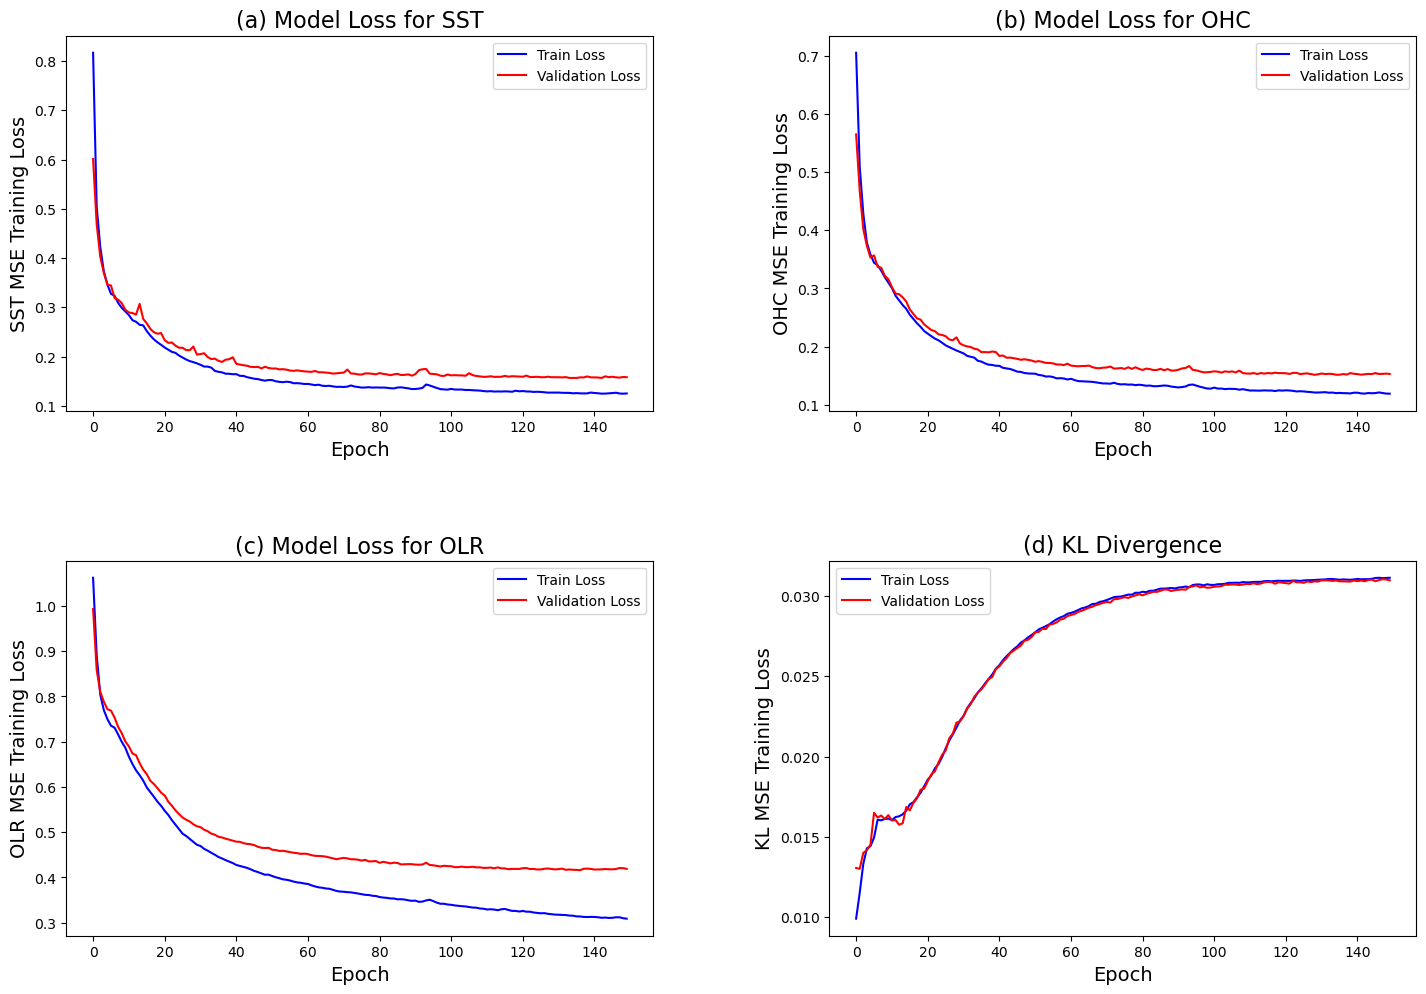

In [30]:
# Create a 4x2 grid of subplots
fig, axes = plt.subplots(2, 2, figsize=(15, 10))
plt.subplots_adjust(left=0.05, right=0.95, bottom=0.05, top=0.95, wspace=0.30, hspace=0.4)

# Flatten the axes array for easier indexing
axes = axes.flatten()

# Plot for SST Loss
axes[0].set_title('(a) Model Loss for SST', fontsize=16)
axes[0].set_xlabel('Epoch', fontsize=14)
axes[0].set_ylabel('SST MSE Training Loss', fontsize=14)
axes[0].plot(vae_model_history.history['sst_loss'], color='blue', label='Train Loss')
axes[0].plot(vae_model_history.history['val_sst_loss'], color='red', label='Validation Loss')
axes[0].legend(loc='best')

# Plot for OHC Loss
axes[1].set_title('(b) Model Loss for OHC', fontsize=16)
axes[1].set_xlabel('Epoch', fontsize=14)
axes[1].set_ylabel('OHC MSE Training Loss', fontsize=14)
axes[1].plot(vae_model_history.history['ohc_loss'], color='blue', label='Train Loss')
axes[1].plot(vae_model_history.history['val_ohc_loss'], color='red', label='Validation Loss')
axes[1].legend(loc='best')

# Plot for OLR Loss
axes[2].set_title('(c) Model Loss for OLR', fontsize=16)
axes[2].set_xlabel('Epoch', fontsize=14)
axes[2].set_ylabel('OLR MSE Training Loss', fontsize=14)
axes[2].plot(vae_model_history.history['olr_loss'], color='blue', label='Train Loss')
axes[2].plot(vae_model_history.history['val_olr_loss'], color='red', label='Validation Loss')
axes[2].legend(loc='best')

# Plot for KL Loss
axes[3].set_title('(d) KL Divergence', fontsize=16)
axes[3].set_xlabel('Epoch', fontsize=14)
axes[3].set_ylabel('KL MSE Training Loss', fontsize=14)
axes[3].plot(vae_model_history.history['kl_loss'], color='blue', label='Train Loss')
axes[3].plot(vae_model_history.history['val_kl_loss'], color='red', label='Validation Loss')
axes[3].legend(loc='best')

# fig.suptitle('Adam, 150 Epochs, 256 Batch Size, 0.3 Validation Split', fontsize=20, y=1.02)
#plt.savefig('/glade/u/home/ewisinski/e3sm_autoencoder/standardscaler/newcoords/randomsampling/fromjohn/scholarly_paper/vae_loss_0507.pdf', bbox_inches='tight', pad_inches=0.1)
plt.show()

## autoencoder variance explained (zero arrays)

In [31]:
encoder_model = Model(inputs=[input_sst, input_ohc, input_olr],
                      outputs=[z]
                     )
#encoder_model.summary()

In [32]:
decoder_model = Model(inputs=[z],
                     outputs=[output_sst,
                              output_ohc,
                              output_olr]
                     )
#decoder_model.summary()

In [33]:
#latent_representations = xr.open_dataset('lr_8dims_kl0.01.nc')

In [34]:
latent_representations = xr.open_dataset('latent_representations_0306_final.nc')

In [35]:
latent_representations = latent_representations['z_mean'].values

## using mean 

## leave one out / variance-loss analysis

In [36]:
# encoded latent representations
N, latent_dim = latent_representations.shape

# full reconstruction baseline
full_sst, _, _ = decoder_model.predict(latent_representations)
full_sst_flat = full_sst.reshape(N, -1)

# baseline for other latent dimensions: mean of each dimension
baseline = latent_representations.mean(axis=0)

# storage for results
pct_contribution_sst = []

for ld in range(latent_dim):
    # copy latent representations and zero out the current dimension
    latents_minus_ld = latent_representations.copy()
    latents_minus_ld[:, ld] = baseline[ld]  # zero out or replace with mean

    # decode the "latent minus this dimension" vectors
    rec_minus_ld, _, _ = decoder_model.predict(latents_minus_ld)
    rec_minus_flat = rec_minus_ld.reshape(N, -1)

    # contribution of this latent dimension = variance lost when removed
    diff = full_sst_flat - rec_minus_flat
    var_contrib = diff.var(axis=0).mean()
    var_total   = full_sst_flat.var(axis=0).mean()

    pct_contribution = 100.0 * var_contrib / var_total
    pct_contribution_sst.append(pct_contribution)

# convert to numpy array for easier plotting
pct_contribution_sst = np.array(pct_contribution_sst)

# print results
for i, val in enumerate(pct_contribution_sst):
    print(f"LD{i}: {val:.2f}% of VAE-reconstructible SST variance")

188/188 [==============================] - 1s 3ms/step
LD0: 14.53% of VAE-reconstructible SST variance
LD1: 2.15% of VAE-reconstructible SST variance
LD2: 0.80% of VAE-reconstructible SST variance
LD3: 1.42% of VAE-reconstructible SST variance
LD4: 0.75% of VAE-reconstructible SST variance
LD5: 3.57% of VAE-reconstructible SST variance
LD6: 1.09% of VAE-reconstructible SST variance
LD7: 4.15% of VAE-reconstructible SST variance
LD8: 1.59% of VAE-reconstructible SST variance
LD9: 2.21% of VAE-reconstructible SST variance
LD10: 1.45% of VAE-reconstructible SST variance
LD11: 3.30% of VAE-reconstructible SST variance
LD12: 1.02% of VAE-reconstructible SST variance
LD13: 2.66% of VAE-reconstructible SST variance
LD14: 2.14% of VAE-reconstructible SST variance
LD15: 1.20% of VAE-reconstructible SST variance
LD16: 3.43% of VAE-reconstructible SST variance
LD17: 1.99% of VAE-reconstructible SST variance
LD18: 1.16% of VAE-reconstructible SST variance
LD19: 3.57% of VAE-reconstructible SST var

In [37]:
pct_contribution_sst.sum()

54.16749705997298

In [38]:
# encoded latent representations
N, latent_dim = latent_representations.shape

# full reconstruction baseline
_, full_ohc, _ = decoder_model.predict(latent_representations)
full_ohc_flat = full_ohc.reshape(N, -1)

# baseline for other latent dimensions: mean of each dimension
baseline = latent_representations.mean(axis=0)

# storage for results
pct_contribution_ohc = []

for ld in range(latent_dim):
    # copy latent representations and zero out the current dimension
    latents_minus_ld = latent_representations.copy()
    latents_minus_ld[:, ld] = baseline[ld]  # zero out or replace with mean

    # decode the "latent minus this dimension" vectors
    _, rec_minus_ohc, _ = decoder_model.predict(latents_minus_ld)
    rec_minus_flat = rec_minus_ohc.reshape(N, -1)

    # contribution of this latent dimension = variance lost when removed
    diff = full_ohc_flat - rec_minus_flat
    var_contrib = diff.var(axis=0).mean()
    var_total   = full_ohc_flat.var(axis=0).mean()

    pct_contribution = 100.0 * var_contrib / var_total
    pct_contribution_ohc.append(pct_contribution)

# convert to numpy array for easier plotting
pct_contribution_ohc = np.array(pct_contribution_ohc)

# print results
for i, val in enumerate(pct_contribution_ohc):
    print(f"LD{i}: {val:.2f}% of VAE-reconstructible OHC variance")

188/188 [==============================] - 1s 4ms/step
LD0: 8.71% of VAE-reconstructible OHC variance
LD1: 7.37% of VAE-reconstructible OHC variance
LD2: 1.88% of VAE-reconstructible OHC variance
LD3: 2.47% of VAE-reconstructible OHC variance
LD4: 1.58% of VAE-reconstructible OHC variance
LD5: 3.34% of VAE-reconstructible OHC variance
LD6: 2.69% of VAE-reconstructible OHC variance
LD7: 4.00% of VAE-reconstructible OHC variance
LD8: 3.93% of VAE-reconstructible OHC variance
LD9: 1.82% of VAE-reconstructible OHC variance
LD10: 5.57% of VAE-reconstructible OHC variance
LD11: 3.32% of VAE-reconstructible OHC variance
LD12: 2.77% of VAE-reconstructible OHC variance
LD13: 4.46% of VAE-reconstructible OHC variance
LD14: 3.19% of VAE-reconstructible OHC variance
LD15: 4.07% of VAE-reconstructible OHC variance
LD16: 1.73% of VAE-reconstructible OHC variance
LD17: 1.15% of VAE-reconstructible OHC variance
LD18: 1.31% of VAE-reconstructible OHC variance
LD19: 7.33% of VAE-reconstructible OHC vari

In [39]:
pct_contribution_ohc.sum()

72.67666131370935

In [40]:
# encoded latent representations
N, latent_dim = latent_representations.shape

# full reconstruction baseline
_, _, full_olr = decoder_model.predict(latent_representations)
full_olr_flat = full_olr.reshape(N, -1)

# baseline for other latent dimensions: mean of each dimension
baseline = latent_representations.mean(axis=0)

# storage for results
pct_contribution_olr = []

for ld in range(latent_dim):
    # copy latent representations and zero out the current dimension
    latents_minus_ld = latent_representations.copy()
    latents_minus_ld[:, ld] = baseline[ld]  # zero out or replace with mean

    # decode the "latent minus this dimension" vectors
    _, _, rec_minus_olr = decoder_model.predict(latents_minus_ld)
    rec_minus_flat = rec_minus_olr.reshape(N, -1)

    # contribution of this latent dimension = variance lost when removed
    diff = full_olr_flat - rec_minus_flat
    var_contrib = diff.var(axis=0).mean()
    var_total   = full_olr_flat.var(axis=0).mean()

    pct_contribution = 100.0 * var_contrib / var_total
    pct_contribution_olr.append(pct_contribution)

# convert to numpy array for easier plotting
pct_contribution_olr = np.array(pct_contribution_olr)

# print results
for i, val in enumerate(pct_contribution_olr):
    print(f"LD{i}: {val:.2f}% of VAE-reconstructible OLR variance")

188/188 [==============================] - 1s 4ms/step
LD0: 10.34% of VAE-reconstructible OLR variance
LD1: 4.06% of VAE-reconstructible OLR variance
LD2: 5.91% of VAE-reconstructible OLR variance
LD3: 3.10% of VAE-reconstructible OLR variance
LD4: 6.11% of VAE-reconstructible OLR variance
LD5: 6.78% of VAE-reconstructible OLR variance
LD6: 4.28% of VAE-reconstructible OLR variance
LD7: 6.53% of VAE-reconstructible OLR variance
LD8: 5.62% of VAE-reconstructible OLR variance
LD9: 4.49% of VAE-reconstructible OLR variance
LD10: 4.43% of VAE-reconstructible OLR variance
LD11: 10.53% of VAE-reconstructible OLR variance
LD12: 3.06% of VAE-reconstructible OLR variance
LD13: 3.98% of VAE-reconstructible OLR variance
LD14: 5.05% of VAE-reconstructible OLR variance
LD15: 3.63% of VAE-reconstructible OLR variance
LD16: 13.49% of VAE-reconstructible OLR variance
LD17: 5.47% of VAE-reconstructible OLR variance
LD18: 5.13% of VAE-reconstructible OLR variance
LD19: 4.90% of VAE-reconstructible OLR v

In [41]:
pct_contribution_olr.sum()

116.87566210514059

## using zero array

In [42]:
# encoded latent representations
N, latent_dim = latent_representations.shape

# full reconstruction baseline
full_sst, _, _ = decoder_model.predict(latent_representations)
full_sst_flat = full_sst.reshape(N, -1)

# baseline for other latent dimensions: mean of each dimension
#baseline = latent_representations.mean(axis=0)

# storage for results
pct_contribution_sst_zero = []

for ld in range(latent_dim):
    
    # copy latent representations and zero out the current dimension
    latents_minus_ld = latent_representations.copy()
    latents_minus_ld[:, ld] = 0.0  # zero out or replace with mean

    # decode the "latent minus this dimension" vectors
    rec_minus_ld, _, _ = decoder_model.predict(latents_minus_ld)
    rec_minus_flat = rec_minus_ld.reshape(N, -1)

    # contribution of this latent dimension = variance lost when removed
    diff = full_sst_flat - rec_minus_flat
    var_contrib = diff.var(axis=0).mean()
    var_total   = full_sst_flat.var(axis=0).mean()

    pct_contribution = 100.0 * var_contrib / var_total
    pct_contribution_sst_zero.append(pct_contribution)

# convert to numpy array for easier plotting
pct_contribution_sst_zero = np.array(pct_contribution_sst_zero)

# print results
for i, val in enumerate(pct_contribution_sst_zero):
    print(f"LD{i}: {val:.2f}% of VAE-reconstructible SST variance")

188/188 [==============================] - 1s 4ms/step
LD0: 14.70% of VAE-reconstructible SST variance
LD1: 2.15% of VAE-reconstructible SST variance
LD2: 0.84% of VAE-reconstructible SST variance
LD3: 1.83% of VAE-reconstructible SST variance
LD4: 1.30% of VAE-reconstructible SST variance
LD5: 3.57% of VAE-reconstructible SST variance
LD6: 1.09% of VAE-reconstructible SST variance
LD7: 4.57% of VAE-reconstructible SST variance
LD8: 1.59% of VAE-reconstructible SST variance
LD9: 2.56% of VAE-reconstructible SST variance
LD10: 1.42% of VAE-reconstructible SST variance
LD11: 3.29% of VAE-reconstructible SST variance
LD12: 1.03% of VAE-reconstructible SST variance
LD13: 2.62% of VAE-reconstructible SST variance
LD14: 2.16% of VAE-reconstructible SST variance
LD15: 1.22% of VAE-reconstructible SST variance
LD16: 3.51% of VAE-reconstructible SST variance
LD17: 2.19% of VAE-reconstructible SST variance
LD18: 1.45% of VAE-reconstructible SST variance
LD19: 3.58% of VAE-reconstructible SST var

In [43]:
pct_contribution_sst_zero.sum()

56.65792767714179

In [44]:
# encoded latent representations
N, latent_dim = latent_representations.shape

# full reconstruction baseline
_, full_ohc, _ = decoder_model.predict(latent_representations)
full_ohc_flat = full_ohc.reshape(N, -1)

# baseline for other latent dimensions: mean of each dimension
baseline = latent_representations.mean(axis=0)

# storage for results
pct_contribution_ohc_zero = []

for ld in range(latent_dim):
    # copy latent representations and zero out the current dimension
    latents_minus_ld = latent_representations.copy()
    latents_minus_ld[:, ld] = 0.0  # zero out or replace with mean

    # decode the "latent minus this dimension" vectors
    _, rec_minus_ohc, _ = decoder_model.predict(latents_minus_ld)
    rec_minus_flat = rec_minus_ohc.reshape(N, -1)

    # contribution of this latent dimension = variance lost when removed
    diff = full_ohc_flat - rec_minus_flat
    var_contrib = diff.var(axis=0).mean()
    var_total   = full_ohc_flat.var(axis=0).mean()

    pct_contribution = 100.0 * var_contrib / var_total
    pct_contribution_ohc_zero.append(pct_contribution)

# convert to numpy array for easier plotting
pct_contribution_ohc_zero = np.array(pct_contribution_ohc_zero)

# print results
for i, val in enumerate(pct_contribution_ohc_zero):
    print(f"LD{i}: {val:.2f}% of VAE-reconstructible OHC variance")

188/188 [==============================] - 1s 4ms/step
LD0: 8.26% of VAE-reconstructible OHC variance
LD1: 7.37% of VAE-reconstructible OHC variance
LD2: 1.95% of VAE-reconstructible OHC variance
LD3: 3.01% of VAE-reconstructible OHC variance
LD4: 2.18% of VAE-reconstructible OHC variance
LD5: 3.25% of VAE-reconstructible OHC variance
LD6: 2.68% of VAE-reconstructible OHC variance
LD7: 4.15% of VAE-reconstructible OHC variance
LD8: 3.90% of VAE-reconstructible OHC variance
LD9: 2.21% of VAE-reconstructible OHC variance
LD10: 5.78% of VAE-reconstructible OHC variance
LD11: 3.33% of VAE-reconstructible OHC variance
LD12: 2.78% of VAE-reconstructible OHC variance
LD13: 4.65% of VAE-reconstructible OHC variance
LD14: 3.13% of VAE-reconstructible OHC variance
LD15: 4.09% of VAE-reconstructible OHC variance
LD16: 1.71% of VAE-reconstructible OHC variance
LD17: 1.46% of VAE-reconstructible OHC variance
LD18: 1.63% of VAE-reconstructible OHC variance
LD19: 7.32% of VAE-reconstructible OHC vari

In [45]:
pct_contribution_ohc_zero.sum()

74.83300931759264

In [46]:
# encoded latent representations
N, latent_dim = latent_representations.shape

# full reconstruction baseline
_, _, full_olr = decoder_model.predict(latent_representations)
full_olr_flat = full_olr.reshape(N, -1)

# baseline for other latent dimensions: mean of each dimension
baseline = latent_representations.mean(axis=0)

# storage for results
pct_contribution_olr_zero = []

for ld in range(latent_dim):
    # copy latent representations and zero out the current dimension
    latents_minus_ld = latent_representations.copy()
    latents_minus_ld[:, ld] = 0.0  # zero out or replace with mean

    # decode the "latent minus this dimension" vectors
    _, _, rec_minus_olr = decoder_model.predict(latents_minus_ld)
    rec_minus_flat = rec_minus_olr.reshape(N, -1)

    # contribution of this latent dimension = variance lost when removed
    diff = full_olr_flat - rec_minus_flat
    var_contrib = diff.var(axis=0).mean()
    var_total   = full_olr_flat.var(axis=0).mean()

    pct_contribution = 100.0 * var_contrib / var_total
    pct_contribution_olr_zero.append(pct_contribution)

# convert to numpy array for easier plotting
pct_contribution_olr_zero = np.array(pct_contribution_olr_zero)

# print results
for i, val in enumerate(pct_contribution_olr_zero):
    print(f"LD{i}: {val:.2f}% of VAE-reconstructible OLR variance")

188/188 [==============================] - 1s 4ms/step
LD0: 10.25% of VAE-reconstructible OLR variance
LD1: 4.11% of VAE-reconstructible OLR variance
LD2: 6.12% of VAE-reconstructible OLR variance
LD3: 3.84% of VAE-reconstructible OLR variance
LD4: 7.85% of VAE-reconstructible OLR variance
LD5: 6.62% of VAE-reconstructible OLR variance
LD6: 4.28% of VAE-reconstructible OLR variance
LD7: 8.43% of VAE-reconstructible OLR variance
LD8: 5.60% of VAE-reconstructible OLR variance
LD9: 5.51% of VAE-reconstructible OLR variance
LD10: 5.58% of VAE-reconstructible OLR variance
LD11: 10.57% of VAE-reconstructible OLR variance
LD12: 3.09% of VAE-reconstructible OLR variance
LD13: 4.32% of VAE-reconstructible OLR variance
LD14: 4.99% of VAE-reconstructible OLR variance
LD15: 3.69% of VAE-reconstructible OLR variance
LD16: 13.36% of VAE-reconstructible OLR variance
LD17: 6.64% of VAE-reconstructible OLR variance
LD18: 6.93% of VAE-reconstructible OLR variance
LD19: 4.90% of VAE-reconstructible OLR v

In [47]:
pct_contribution_olr_zero.sum()

126.69093327505959

In [48]:
print(pct_contribution_sst.shape,
      pct_contribution_ohc.shape,
      pct_contribution_olr.shape,
      pct_contribution_sst_zero.shape,
      pct_contribution_ohc_zero.shape,
      pct_contribution_olr_zero.shape
     )

(20,) (20,) (20,) (20,) (20,) (20,)


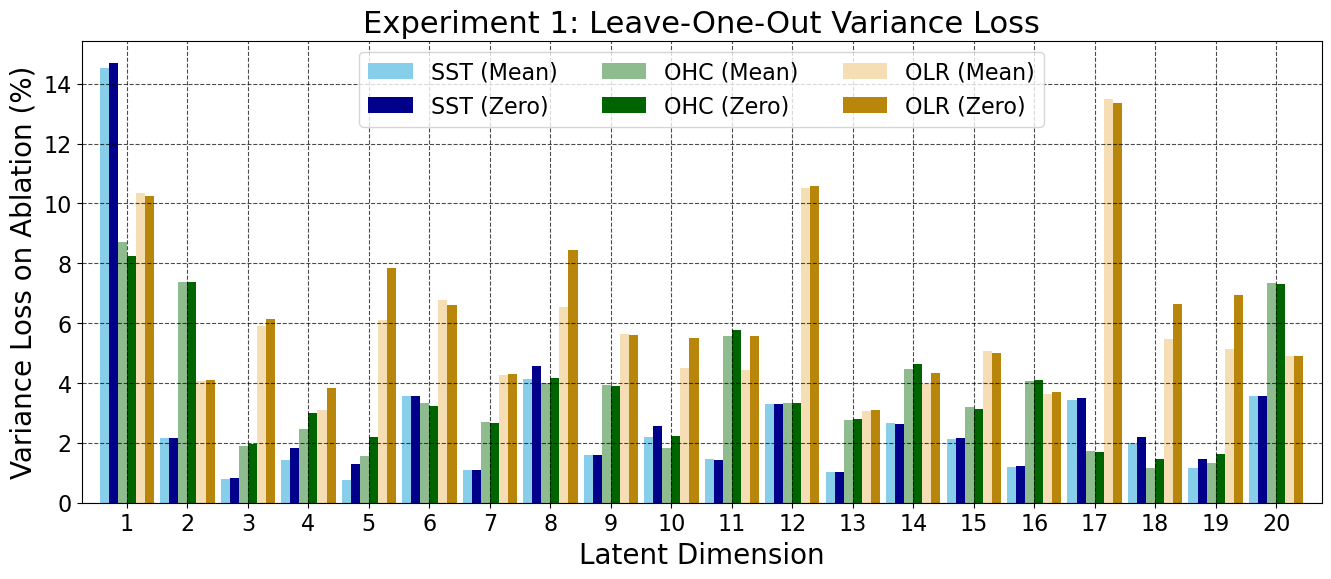

In [49]:
n_pcs = 20
x = np.arange(1, n_pcs + 1)

n_bars = 6
width = 0.15

offsets = np.linspace(
    - (n_bars - 1) / 2 * width,
    + (n_bars - 1) / 2 * width,
    n_bars
)

plt.figure(figsize=(16, 6))

plt.bar(x + offsets[0], pct_contribution_sst, width, label='SST (Mean)', color='skyblue')
plt.bar(x + offsets[1], pct_contribution_sst_zero,  width, label='SST (Zero)', color='darkblue')

plt.bar(x + offsets[2], pct_contribution_ohc, width, label='OHC (Mean)', color='darkseagreen')
plt.bar(x + offsets[3], pct_contribution_ohc_zero,  width, label='OHC (Zero)', color='darkgreen')

plt.bar(x + offsets[4], pct_contribution_olr, width, label='OLR (Mean)', color='wheat')
plt.bar(x + offsets[5], pct_contribution_olr_zero,  width, label='OLR (Zero)', color='darkgoldenrod')

#plt.bar(x + offsets[3], pct_contribution_sst_zero,  width, label='SST (Zero)', color='wheat')
#plt.bar(x + offsets[4], pct_contribution_ohc_zero,  width, label='OHC (Zero)', color='darkorange')
#plt.bar(x + offsets[5], pct_contribution_olr_zero,  width, label='OLR (Zero)', color='darkgoldenrod')

plt.xlabel('Latent Dimension', fontsize=20)
plt.ylabel('Variance Loss on Ablation (%)', fontsize=20)
plt.title(r'Experiment 1: Leave-One-Out Variance Loss', fontsize=22)
plt.xticks(x, np.arange(1, n_pcs+1), fontsize=16)
plt.yticks(fontsize=16)

left_edge  = x[0] + offsets.min() - width / 2
right_edge = x[-1] + offsets.max() + width / 2
pad = 0.3  # try 0.2–0.5; this is in x-axis units
plt.xlim(left_edge - pad, right_edge + pad)


#plt.ylim(0, 16)
plt.grid(True, linestyle='--', color='black', alpha=0.7)
plt.legend(fontsize=16, ncols=3, loc='upper center')
plt.savefig('exp1_0309.pdf', bbox_inches='tight')
plt.show()

## how much variance in SST can LD(x) generate on its own?

## What fraction of the full reconstructed SST variance can be generated when only LD𝑘 is active and all others are mean/zero?

In [50]:
# encoded latent representations
N, latent_dim = latent_representations.shape

# full reconstruction baseline
full_sst, _, _ = decoder_model.predict(latent_representations)
full_sst_flat = full_sst.reshape(N, -1)

# total variance from full VAE reconstruction
var_total = full_sst_flat.var(axis=0).mean()

# storage
pct_contribution_only_sst_zero = []

for ld in range(latent_dim):

    # new matrix: zero everything except the dimension of interest
    latents_only_ld = np.zeros_like(latent_representations)
    latents_only_ld[:, ld] = latent_representations[:, ld]   # keep only LD_k

    # decode
    rec_only_ld, _, _ = decoder_model.predict(latents_only_ld)
    rec_only_flat = rec_only_ld.reshape(N, -1)

    # variance captured by this LD alone
    var_ld = rec_only_flat.var(axis=0).mean()

    pct_contribution = 100.0 * var_ld / var_total
    pct_contribution_only_sst_zero.append(pct_contribution)

# convert to array
pct_contribution_only_sst_zero = np.array(pct_contribution_only_sst_zero)

# print
for i, val in enumerate(pct_contribution_only_sst_zero):
    print(f"LD{i}: {val:.2f}% of VAE-reconstructible SST variance when isolated (zero-ed out)")

188/188 [==============================] - 1s 3ms/step
LD0: 67.53% of VAE-reconstructible SST variance when isolated (zero-ed out)
LD1: 10.38% of VAE-reconstructible SST variance when isolated (zero-ed out)
LD2: 5.04% of VAE-reconstructible SST variance when isolated (zero-ed out)
LD3: 6.65% of VAE-reconstructible SST variance when isolated (zero-ed out)
LD4: 2.32% of VAE-reconstructible SST variance when isolated (zero-ed out)
LD5: 21.14% of VAE-reconstructible SST variance when isolated (zero-ed out)
LD6: 7.35% of VAE-reconstructible SST variance when isolated (zero-ed out)
LD7: 10.28% of VAE-reconstructible SST variance when isolated (zero-ed out)
LD8: 7.73% of VAE-reconstructible SST variance when isolated (zero-ed out)
LD9: 9.57% of VAE-reconstructible SST variance when isolated (zero-ed out)
LD10: 6.76% of VAE-reconstructible SST variance when isolated (zero-ed out)
LD11: 16.22% of VAE-reconstructible SST variance when isolated (zero-ed out)
LD12: 6.60% of VAE-reconstructible SST

In [51]:
pct_contribution_only_sst_zero.sum()

254.31740195555923

In [52]:
# encoded latent representations
N, latent_dim = latent_representations.shape

# full reconstruction baseline
full_sst, _, _ = decoder_model.predict(latent_representations)
full_sst_flat = full_sst.reshape(N, -1)

# total variance from full VAE reconstruction
var_total = full_sst_flat.var(axis=0).mean()

# mean vector for each latent dimension
mean_vec = np.mean(latent_representations, axis=0)

# storage
pct_contribution_only_sst_mean = []

for ld in range(latent_dim):

    # start with NxD matrix of mean values
    latents_only_ld = np.tile(mean_vec, (N, 1))

    # insert the actual LD_k values
    latents_only_ld[:, ld] = latent_representations[:, ld]

    # decode
    rec_only_ld, _, _ = decoder_model.predict(latents_only_ld)
    rec_only_flat = rec_only_ld.reshape(N, -1)

    # variance captured by this LD alone
    var_ld = rec_only_flat.var(axis=0).mean()

    pct_contribution = 100.0 * var_ld / var_total
    pct_contribution_only_sst_mean.append(pct_contribution)

# convert to array
pct_contribution_only_sst_mean = np.array(pct_contribution_only_sst_mean)

# print
for i, val in enumerate(pct_contribution_only_sst_mean):
    print(f"LD{i}: {val:.2f}% of VAE-reconstructible SST variance when isolated (mean background)")

188/188 [==============================] - 1s 3ms/step
LD0: 22.85% of VAE-reconstructible SST variance when isolated (mean background)
LD1: 2.32% of VAE-reconstructible SST variance when isolated (mean background)
LD2: 0.93% of VAE-reconstructible SST variance when isolated (mean background)
LD3: 1.45% of VAE-reconstructible SST variance when isolated (mean background)
LD4: 0.56% of VAE-reconstructible SST variance when isolated (mean background)
LD5: 4.03% of VAE-reconstructible SST variance when isolated (mean background)
LD6: 1.32% of VAE-reconstructible SST variance when isolated (mean background)
LD7: 3.35% of VAE-reconstructible SST variance when isolated (mean background)
LD8: 1.80% of VAE-reconstructible SST variance when isolated (mean background)
LD9: 3.11% of VAE-reconstructible SST variance when isolated (mean background)
LD10: 1.70% of VAE-reconstructible SST variance when isolated (mean background)
LD11: 4.60% of VAE-reconstructible SST variance when isolated (mean backgr

In [53]:
pct_contribution_only_sst_mean.sum()

71.67231297229497

## OHC

In [54]:
# encoded latent representations
N, latent_dim = latent_representations.shape

# full reconstruction baseline
_, full_ohc, _ = decoder_model.predict(latent_representations)
full_ohc_flat = full_ohc.reshape(N, -1)

# total variance from full VAE reconstruction
var_total = full_ohc_flat.var(axis=0).mean()

# storage
pct_contribution_only_ohc_zero = []

for ld in range(latent_dim):

    # new matrix: zero everything except the dimension of interest
    latents_only_ld = np.zeros_like(latent_representations)
    latents_only_ld[:, ld] = latent_representations[:, ld]   # keep only LD_k

    # decode
    _, rec_only_ld, _ = decoder_model.predict(latents_only_ld)
    rec_only_flat = rec_only_ld.reshape(N, -1)

    # variance captured by this LD alone
    var_ld = rec_only_flat.var(axis=0).mean()

    pct_contribution = 100.0 * var_ld / var_total
    pct_contribution_only_ohc_zero.append(pct_contribution)

# convert to array
pct_contribution_only_ohc_zero = np.array(pct_contribution_only_ohc_zero)

# print
for i, val in enumerate(pct_contribution_only_ohc_zero):
    print(f"LD{i}: {val:.2f}% of VAE-reconstructible OHC variance when isolated (zero-ed out)")

188/188 [==============================] - 1s 3ms/step
LD0: 37.18% of VAE-reconstructible OHC variance when isolated (zero-ed out)
LD1: 31.34% of VAE-reconstructible OHC variance when isolated (zero-ed out)
LD2: 10.26% of VAE-reconstructible OHC variance when isolated (zero-ed out)
LD3: 8.24% of VAE-reconstructible OHC variance when isolated (zero-ed out)
LD4: 4.24% of VAE-reconstructible OHC variance when isolated (zero-ed out)
LD5: 14.51% of VAE-reconstructible OHC variance when isolated (zero-ed out)
LD6: 16.79% of VAE-reconstructible OHC variance when isolated (zero-ed out)
LD7: 5.97% of VAE-reconstructible OHC variance when isolated (zero-ed out)
LD8: 23.31% of VAE-reconstructible OHC variance when isolated (zero-ed out)
LD9: 6.73% of VAE-reconstructible OHC variance when isolated (zero-ed out)
LD10: 24.78% of VAE-reconstructible OHC variance when isolated (zero-ed out)
LD11: 16.95% of VAE-reconstructible OHC variance when isolated (zero-ed out)
LD12: 13.15% of VAE-reconstructible

In [55]:
pct_contribution_only_ohc_zero.sum()

316.8101012938105

In [56]:
# encoded latent representations
N, latent_dim = latent_representations.shape

# full reconstruction baseline
_, full_ohc, _ = decoder_model.predict(latent_representations)
full_ohc_flat = full_ohc.reshape(N, -1)

# total variance from full VAE reconstruction
var_total = full_ohc_flat.var(axis=0).mean()

# mean vector for each latent dimension
mean_vec = np.mean(latent_representations, axis=0)

# storage
pct_contribution_only_ohc_mean = []

for ld in range(latent_dim):

    # start with NxD matrix of mean values
    latents_only_ld = np.tile(mean_vec, (N, 1))

    # insert the actual LD_k values
    latents_only_ld[:, ld] = latent_representations[:, ld]

    # decode
    _, rec_only_ld, _ = decoder_model.predict(latents_only_ld)
    rec_only_flat = rec_only_ld.reshape(N, -1)

    # variance captured by this LD alone
    var_ld = rec_only_flat.var(axis=0).mean()

    pct_contribution = 100.0 * var_ld / var_total
    pct_contribution_only_ohc_mean.append(pct_contribution)

# convert to array
pct_contribution_only_ohc_mean = np.array(pct_contribution_only_ohc_mean)

# print
for i, val in enumerate(pct_contribution_only_ohc_mean):
    print(f"LD{i}: {val:.2f}% of VAE-reconstructible OHC variance when isolated (mean background)")

188/188 [==============================] - 1s 4ms/step
LD0: 12.25% of VAE-reconstructible OHC variance when isolated (mean background)
LD1: 8.98% of VAE-reconstructible OHC variance when isolated (mean background)
LD2: 2.61% of VAE-reconstructible OHC variance when isolated (mean background)
LD3: 2.49% of VAE-reconstructible OHC variance when isolated (mean background)
LD4: 1.86% of VAE-reconstructible OHC variance when isolated (mean background)
LD5: 4.11% of VAE-reconstructible OHC variance when isolated (mean background)
LD6: 3.40% of VAE-reconstructible OHC variance when isolated (mean background)
LD7: 2.55% of VAE-reconstructible OHC variance when isolated (mean background)
LD8: 5.06% of VAE-reconstructible OHC variance when isolated (mean background)
LD9: 2.19% of VAE-reconstructible OHC variance when isolated (mean background)
LD10: 7.65% of VAE-reconstructible OHC variance when isolated (mean background)
LD11: 4.73% of VAE-reconstructible OHC variance when isolated (mean backgr

In [57]:
pct_contribution_only_ohc_mean.sum()

91.51099364106668

## OLR

In [58]:
# encoded latent representations
N, latent_dim = latent_representations.shape

# full reconstruction baseline
_, _, full_olr = decoder_model.predict(latent_representations)
full_olr_flat = full_olr.reshape(N, -1)

# total variance from full VAE reconstruction
var_total = full_olr_flat.var(axis=0).mean()

# storage
pct_contribution_only_olr_zero = []

for ld in range(latent_dim):

    # new matrix: zero everything except the dimension of interest
    latents_only_ld = np.zeros_like(latent_representations)
    latents_only_ld[:, ld] = latent_representations[:, ld]   # keep only LD_k

    # decode
    _, _, rec_only_ld = decoder_model.predict(latents_only_ld)
    rec_only_flat = rec_only_ld.reshape(N, -1)

    # variance captured by this LD alone
    var_ld = rec_only_flat.var(axis=0).mean()

    pct_contribution = 100.0 * var_ld / var_total
    pct_contribution_only_olr_zero.append(pct_contribution)

# convert to array
pct_contribution_only_olr_zero = np.array(pct_contribution_only_olr_zero)

# print
for i, val in enumerate(pct_contribution_only_olr_zero):
    print(f"LD{i}: {val:.2f}% of VAE-reconstructible OLR variance when isolated (zero-ed out)")

188/188 [==============================] - 1s 4ms/step
LD0: 58.25% of VAE-reconstructible OLR variance when isolated (zero-ed out)
LD1: 23.89% of VAE-reconstructible OLR variance when isolated (zero-ed out)
LD2: 34.10% of VAE-reconstructible OLR variance when isolated (zero-ed out)
LD3: 15.57% of VAE-reconstructible OLR variance when isolated (zero-ed out)
LD4: 27.43% of VAE-reconstructible OLR variance when isolated (zero-ed out)
LD5: 54.34% of VAE-reconstructible OLR variance when isolated (zero-ed out)
LD6: 34.58% of VAE-reconstructible OLR variance when isolated (zero-ed out)
LD7: 31.37% of VAE-reconstructible OLR variance when isolated (zero-ed out)
LD8: 42.33% of VAE-reconstructible OLR variance when isolated (zero-ed out)
LD9: 22.26% of VAE-reconstructible OLR variance when isolated (zero-ed out)
LD10: 32.37% of VAE-reconstructible OLR variance when isolated (zero-ed out)
LD11: 75.18% of VAE-reconstructible OLR variance when isolated (zero-ed out)
LD12: 26.68% of VAE-reconstruct

In [59]:
pct_contribution_only_olr_zero.sum()

761.8063228591456

In [60]:
# encoded latent representations
N, latent_dim = latent_representations.shape

# full reconstruction baseline
_, _, full_olr = decoder_model.predict(latent_representations)
full_olr_flat = full_olr.reshape(N, -1)

# total variance from full VAE reconstruction
var_total = full_olr_flat.var(axis=0).mean()

# mean vector for each latent dimension
mean_vec = np.mean(latent_representations, axis=0)

# storage
pct_contribution_only_olr_mean = []

for ld in range(latent_dim):

    # start with NxD matrix of mean values
    latents_only_ld = np.tile(mean_vec, (N, 1))

    # insert the actual LD_k values
    latents_only_ld[:, ld] = latent_representations[:, ld]

    # decode
    _, _, rec_only_ld = decoder_model.predict(latents_only_ld)
    rec_only_flat = rec_only_ld.reshape(N, -1)

    # variance captured by this LD alone
    var_ld = rec_only_flat.var(axis=0).mean()

    pct_contribution = 100.0 * var_ld / var_total
    pct_contribution_only_olr_mean.append(pct_contribution)

# convert to array
pct_contribution_only_olr_mean = np.array(pct_contribution_only_olr_mean)

# print
for i, val in enumerate(pct_contribution_only_olr_mean):
    print(f"LD{i}: {val:.2f}% of VAE-reconstructible OLR variance when isolated (mean background)")

188/188 [==============================] - 1s 4ms/step
LD0: 12.24% of VAE-reconstructible OLR variance when isolated (mean background)
LD1: 4.29% of VAE-reconstructible OLR variance when isolated (mean background)
LD2: 7.53% of VAE-reconstructible OLR variance when isolated (mean background)
LD3: 3.47% of VAE-reconstructible OLR variance when isolated (mean background)
LD4: 10.55% of VAE-reconstructible OLR variance when isolated (mean background)
LD5: 9.24% of VAE-reconstructible OLR variance when isolated (mean background)
LD6: 5.09% of VAE-reconstructible OLR variance when isolated (mean background)
LD7: 7.40% of VAE-reconstructible OLR variance when isolated (mean background)
LD8: 7.61% of VAE-reconstructible OLR variance when isolated (mean background)
LD9: 5.19% of VAE-reconstructible OLR variance when isolated (mean background)
LD10: 5.58% of VAE-reconstructible OLR variance when isolated (mean background)
LD11: 12.92% of VAE-reconstructible OLR variance when isolated (mean back

In [61]:
pct_contribution_only_olr_mean.sum()

147.72405004086318

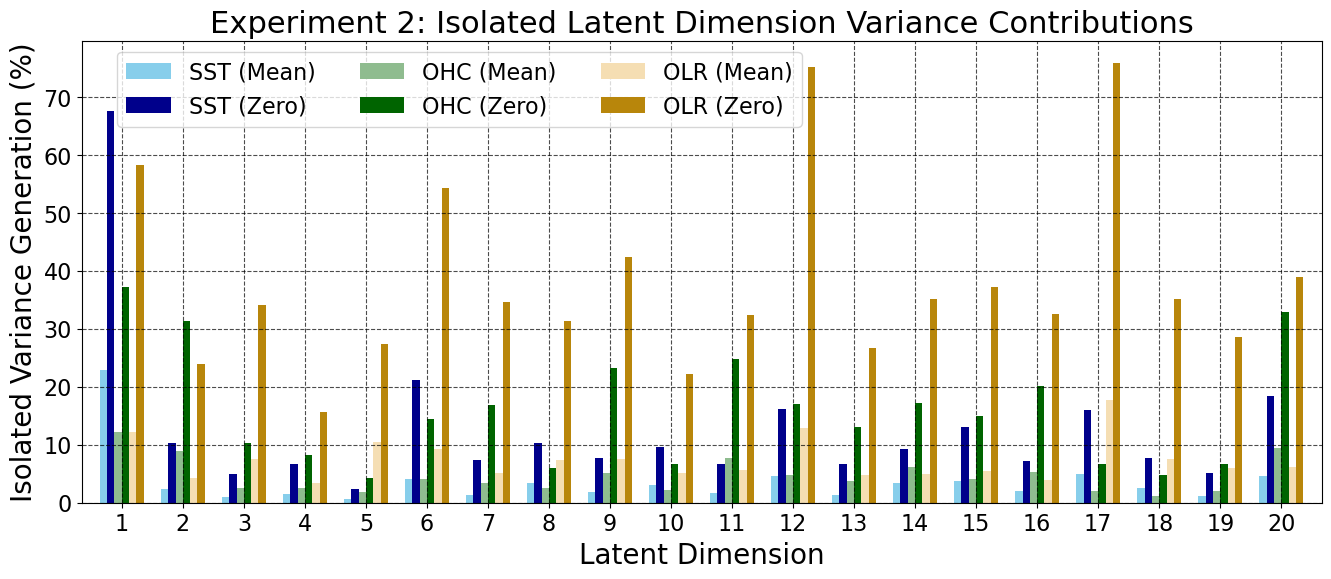

In [62]:
n_pcs = 20
x = np.arange(1, n_pcs + 1)

n_bars = 6
width = 0.12

offsets = np.linspace(
    - (n_bars - 1) / 2 * width,
    + (n_bars - 1) / 2 * width,
    n_bars
)

plt.figure(figsize=(16, 6))

plt.bar(x + offsets[0], pct_contribution_only_sst_mean, width, label='SST (Mean)', color='skyblue')
plt.bar(x + offsets[1], pct_contribution_only_sst_zero,  width, label='SST (Zero)', color='darkblue')

plt.bar(x + offsets[2], pct_contribution_only_ohc_mean, width, label='OHC (Mean)', color='darkseagreen')
plt.bar(x + offsets[3], pct_contribution_only_ohc_zero,  width, label='OHC (Zero)', color='darkgreen')

plt.bar(x + offsets[4], pct_contribution_only_olr_mean, width, label='OLR (Mean)', color='wheat')
plt.bar(x + offsets[5], pct_contribution_only_olr_zero,  width, label='OLR (Zero)', color='darkgoldenrod')

plt.xlabel('Latent Dimension', fontsize=20)
plt.ylabel('Isolated Variance Generation (%)', fontsize=20)
plt.title(r'Experiment 2: Isolated Latent Dimension Variance Contributions', fontsize=22)
plt.xticks(x, np.arange(1, n_pcs +1), fontsize=16)
plt.yticks(fontsize=16)
#plt.ylim(0, 85)

left_edge  = x[0] + offsets.min() - width / 2
right_edge = x[-1] + offsets.max() + width / 2
pad = 0.3  # try 0.2–0.5; this is in x-axis units
plt.xlim(left_edge - pad, right_edge + pad)


plt.legend(fontsize=16, ncols=3, loc='upper left', bbox_to_anchor=(0.02, 1.0))
plt.grid(True, linestyle='--', color='black', alpha=0.7)
plt.savefig('exp2_0309.pdf', bbox_inches='tight')
plt.show()